# NB07b -- ArcPL bias probe

**Goal.** Diagnose the +50 C / +1.5 kbar systematic bias visible on ArcPL external validation
but absent from the within-distribution NB07 test set. Seven probes, no model changes.

**Inputs.** `results/nb04_arcpl_opx_liq_predictions_forest.csv` (ArcPL pred+obs, n=197);
`results/nb07_test_predictions.csv` (held-out test, n=174 -- serves as the train-distribution
proxy since `nb07_oof_predictions_train.csv` does not exist in this repo).

**Outputs.** CSVs to `results/`, figures to `figures/`, printed recommendation at the end.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold

ROOT = Path('..').resolve() if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
RESULTS = ROOT / 'results'
FIGURES = ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)

arcpl = pd.read_csv(RESULTS / 'nb04_arcpl_opx_liq_predictions_forest.csv')
test  = pd.read_csv(RESULTS / 'nb07_test_predictions.csv')

arcpl['T_resid'] = arcpl['T_pred'] - arcpl['T_C']
arcpl['P_resid'] = arcpl['P_pred'] - arcpl['P_kbar']
test['T_resid']  = test['T_rf_raw'] - test['T_true']
test['P_resid']  = test['P_rf_raw'] - test['P_true']
print(f'ArcPL n={len(arcpl)}; Test n={len(test)}')
print(f'ArcPL columns: T_pred={"T_pred" in arcpl.columns} P_pred={"P_pred" in arcpl.columns} Citation={"Citation" in arcpl.columns}')

ArcPL n=197; Test n=174
ArcPL columns: T_pred=True P_pred=True Citation=True


## Probe 1 -- Quantify the bias precisely

In [2]:
def _stats(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return {
        'mean':    float(np.mean(x)),
        'median':  float(np.median(x)),
        'std':     float(np.std(x, ddof=1)),
        'mad':     float(np.mean(np.abs(x - np.mean(x)))),
        'q25':     float(np.percentile(x, 25)),
        'q50':     float(np.percentile(x, 50)),
        'q75':     float(np.percentile(x, 75)),
        'n':       int(len(x)),
    }

probe1_rows = []
for tgt, arc_col, test_col in [('T', 'T_resid', 'T_resid'), ('P', 'P_resid', 'P_resid')]:
    s_arc  = _stats(arcpl[arc_col])
    s_test = _stats(test[test_col])
    probe1_rows.append({'target': tgt, 'source': 'ArcPL',     **s_arc})
    probe1_rows.append({'target': tgt, 'source': 'Test_set',  **s_test})
probe1 = pd.DataFrame(probe1_rows)
probe1.to_csv(RESULTS / 'nb07b_probe1_bias_stats.csv', index=False)

for tgt in ['T', 'P']:
    unit = 'C' if tgt == 'T' else 'kbar'
    a = probe1[(probe1.target == tgt) & (probe1.source == 'ArcPL')].iloc[0]
    t = probe1[(probe1.target == tgt) & (probe1.source == 'Test_set')].iloc[0]
    print(f'\n{tgt} residual statistics ({unit}):')
    print(f'                       ArcPL (n={int(a['n'])})     Test set (n={int(t['n'])})')
    print(f'  Mean residual:       {a['mean']:+9.2f}       {t['mean']:+9.2f}')
    print(f'  Median residual:     {a['median']:+9.2f}       {t['median']:+9.2f}')
    print(f'  Std of residual:     {a['std']:9.2f}       {t['std']:9.2f}')
    print(f'  Mean abs deviation:  {a['mad']:9.2f}       {t['mad']:9.2f}')
    print(f'  25/50/75 pct:        {a.q25:+.1f}/{a.q50:+.1f}/{a.q75:+.1f}    {t.q25:+.1f}/{t.q50:+.1f}/{t.q75:+.1f}')


T residual statistics (C):
                       ArcPL (n=197)     Test set (n=174)
  Mean residual:          +37.32           -5.53
  Median residual:        +43.47          -14.97
  Std of residual:         52.84           88.30
  Mean abs deviation:      42.61           59.71
  25/50/75 pct:        -1.3/+43.5/+75.8    -48.6/-15.0/+29.1

P residual statistics (kbar):
                       ArcPL (n=197)     Test set (n=174)
  Mean residual:           +0.69           -0.51
  Median residual:         +1.13           +0.00
  Std of residual:          2.54            5.76
  Mean abs deviation:       1.91            3.85
  25/50/75 pct:        -0.6/+1.1/+2.2    -3.3/+0.0/+1.3


## Probe 2 -- Is the bias driven by outliers?

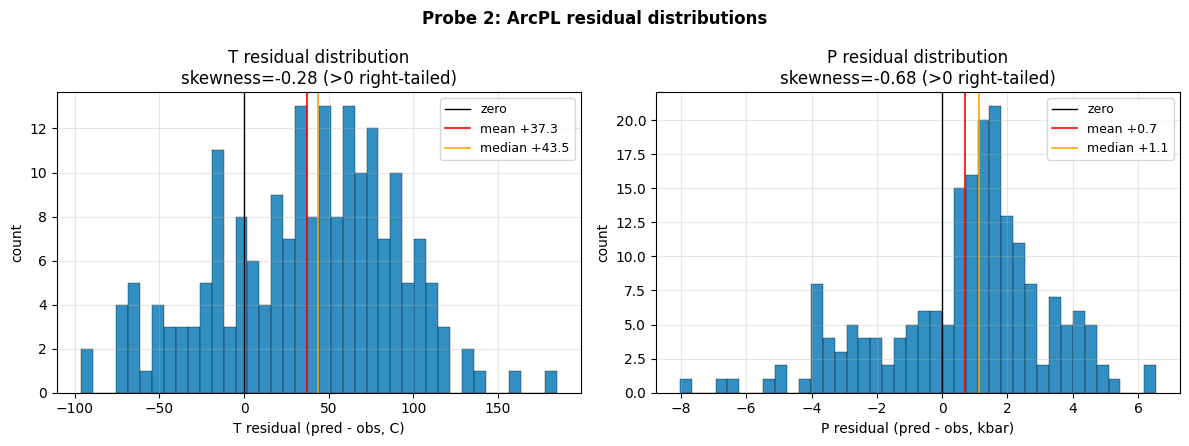


5 most OVER-predicted T samples (largest positive T_resid):
            Citation   T_C      T_pred    T_resid  P_kbar   P_pred  P_resid  liq_SiO2  liq_MgO  H2O_Liq   Mg_num
Sisson2005_notinLEPR 825.0 1009.947094 184.947094   7.000 9.606036 2.606036 75.300000 0.410000      6.8 0.701601
Sisson2005_notinLEPR 825.0  987.947159 162.947159   7.000 8.491374 1.491374 73.100000 0.490000      8.7 0.682974
Cadoux2014_notinLEPR 850.0  991.022019 141.022019   0.972 3.517420 2.545420 74.133363 0.350846      3.4 0.729977
Cadoux2014_notinLEPR 850.0  984.567616 134.567616   0.972 5.268701 4.296701 74.477263 0.351488      3.6 0.731960
Cadoux2014_notinLEPR 850.0  981.782349 131.782349   0.972 3.750112 2.778112 75.076904 0.374194      3.3 0.728650

5 most UNDER-predicted T samples (largest negative T_resid):
             Citation    T_C      T_pred    T_resid  P_kbar    P_pred   P_resid  liq_SiO2  liq_MgO  H2O_Liq   Mg_num
Blatter2023_notinLEPR 1100.0 1003.475185 -96.524815    14.6  7.683527 -6.916473   

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, tgt, unit, col in [(axes[0], 'T', 'C', 'T_resid'),
                            (axes[1], 'P', 'kbar', 'P_resid')]:
    x = arcpl[col].values
    x = x[np.isfinite(x)]
    mean = float(np.mean(x)); median = float(np.median(x))
    skew = float(stats.skew(x))
    ax.hist(x, bins=40, color='#0072B2', edgecolor='black', linewidth=0.3, alpha=0.8)
    ax.axvline(0,      color='k',    lw=1.0, label='zero')
    ax.axvline(mean,   color='red',  lw=1.2, label=f'mean {mean:+.1f}')
    ax.axvline(median, color='orange', lw=1.2, label=f'median {median:+.1f}')
    ax.set_xlabel(f'{tgt} residual (pred - obs, {unit})')
    ax.set_ylabel('count')
    ax.set_title(f'{tgt} residual distribution\nskewness={skew:+.2f} (>0 right-tailed)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle('Probe 2: ArcPL residual distributions', fontweight='bold')
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(FIGURES / f'fig_nb07b_arcpl_residual_hist.{ext}',
                dpi=300 if ext == 'png' else None, bbox_inches='tight')
plt.show(); plt.close(fig)

# Top-5 most over / under predicted samples
probe2_cols = [c for c in ['Citation', 'T_C', 'T_pred', 'T_resid', 'P_kbar', 'P_pred', 'P_resid',
                            'liq_SiO2', 'liq_MgO', 'H2O_Liq', 'Mg_num']
                if c in arcpl.columns]
print('\n5 most OVER-predicted T samples (largest positive T_resid):')
over_T = arcpl.nlargest(5, 'T_resid')[probe2_cols]
print(over_T.to_string(index=False))
print('\n5 most UNDER-predicted T samples (largest negative T_resid):')
under_T = arcpl.nsmallest(5, 'T_resid')[probe2_cols]
print(under_T.to_string(index=False))
print('\n5 most OVER-predicted P samples:')
over_P = arcpl.nlargest(5, 'P_resid')[probe2_cols]
print(over_P.to_string(index=False))
print('\n5 most UNDER-predicted P samples:')
under_P = arcpl.nsmallest(5, 'P_resid')[probe2_cols]
print(under_P.to_string(index=False))

pd.concat([
    over_T.assign(sign='T_over'),  under_T.assign(sign='T_under'),
    over_P.assign(sign='P_over'),  under_P.assign(sign='P_under'),
]).to_csv(RESULTS / 'nb07b_probe2_extreme_residuals.csv', index=False)

## Probe 3 -- Does the bias scale with the prediction value?

T pearson(pred, residual) = -0.089 (p=0.211); linear fit residual = -0.0503 * pred + +88.95
T bias by prediction quintile:
                              mean_resid  median_resid     sem   ci_lo   ci_hi     n
_T_bin                                                                              
(904.0880000000001, 936.504]      60.725        68.464   5.378  50.183  71.266  40.0
(936.504, 981.95]                 34.045        38.825   8.448  17.486  50.604  39.0
(981.95, 1022.732]                38.492        43.466  11.041  16.851  60.133  39.0
(1022.732, 1126.865]               7.669        22.027   7.881  -7.777  23.115  39.0
(1126.865, 1230.807]              44.879        47.492   6.437  32.262  57.496  40.0


P pearson(pred, residual) = -0.214 (p=0.00249); linear fit residual = -0.2145 * pred + +2.27
P bias by prediction quintile:
                 mean_resid  median_resid    sem  ci_lo  ci_hi     n
_P_bin                                                              
(2.838, 4.551]        1.016         1.270  0.185  0.653  1.379  40.0
(4.551, 7.461]        1.984         2.204  0.338  1.322  2.647  39.0
(7.461, 8.187]        0.594         0.844  0.491 -0.368  1.555  39.0
(8.187, 9.103]        0.414         1.308  0.458 -0.484  1.311  39.0
(9.103, 13.119]      -0.520        -0.465  0.395 -1.295  0.254  40.0


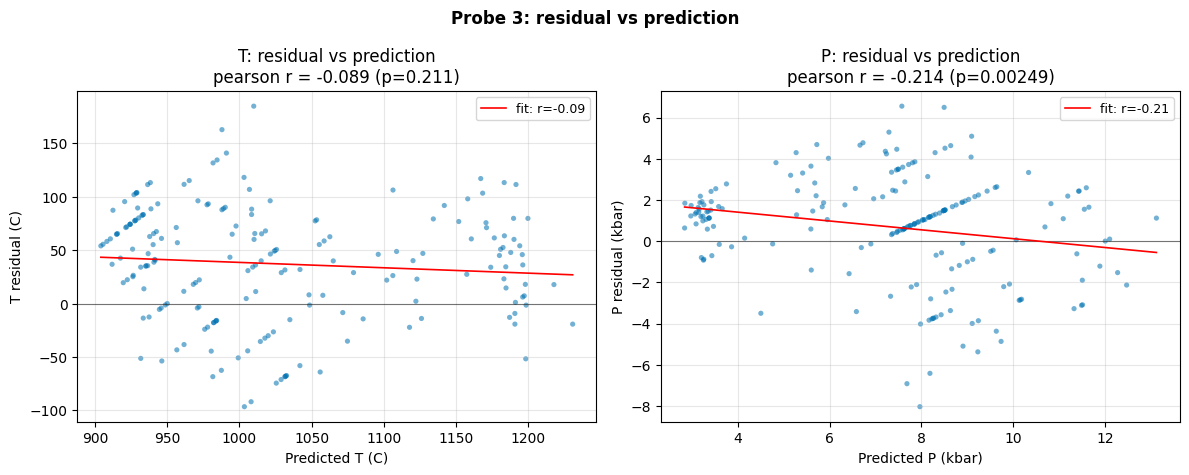

292

In [4]:
probe3_rows = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, tgt, unit, pred_col, resid_col in [
        (axes[0], 'T', 'C', 'T_pred', 'T_resid'),
        (axes[1], 'P', 'kbar', 'P_pred', 'P_resid')]:
    x = arcpl[pred_col].values.astype(float)
    y = arcpl[resid_col].values.astype(float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    r, p = stats.pearsonr(x, y)
    lr_slope, lr_intercept, *_ = stats.linregress(x, y)
    print(f'{tgt} pearson(pred, residual) = {r:+.3f} (p={p:.3g}); '
          f'linear fit residual = {lr_slope:+.4f} * pred + {lr_intercept:+.2f}')
    # Quintile binning
    arcpl[f'_{tgt}_bin'] = pd.qcut(arcpl[pred_col], q=5, duplicates='drop')
    binned = arcpl.groupby(f'_{tgt}_bin', observed=True).apply(
        lambda g: pd.Series({
            'mean_resid':   float(g[resid_col].mean()),
            'median_resid': float(g[resid_col].median()),
            'sem':          float(g[resid_col].sem()),
            'ci_lo':        float(g[resid_col].mean() - 1.96 * g[resid_col].sem()),
            'ci_hi':        float(g[resid_col].mean() + 1.96 * g[resid_col].sem()),
            'n':            int(len(g)),
        })
    )
    print(f'{tgt} bias by prediction quintile:')
    print(binned.round(3).to_string())
    for _, row in binned.reset_index().iterrows():
        probe3_rows.append({'target': tgt, 'bin': str(row[f'_{tgt}_bin']),
                            **{k: row[k] for k in ['mean_resid', 'median_resid', 'sem',
                                                    'ci_lo', 'ci_hi', 'n']}})
    ax.scatter(x, y, s=14, alpha=0.55, color='#0072B2', edgecolor='none')
    ax.axhline(0, color='k', lw=0.8, alpha=0.5)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, lr_slope * xs + lr_intercept, color='red', lw=1.2,
            label=f'fit: r={r:+.2f}')
    ax.set_xlabel(f'Predicted {tgt} ({unit})')
    ax.set_ylabel(f'{tgt} residual ({unit})')
    ax.set_title(f'{tgt}: residual vs prediction\npearson r = {r:+.3f} (p={p:.3g})')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Probe 3: residual vs prediction', fontweight='bold')
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(FIGURES / f'fig_nb07b_bias_vs_prediction.{ext}',
                dpi=300 if ext == 'png' else None, bbox_inches='tight')
plt.show(); plt.close(fig)

pd.DataFrame(probe3_rows).to_csv(RESULTS / 'nb07b_probe3_bias_by_quintile.csv', index=False)

# Also persist the linear-fit params for Probe 5 use
p3_fit = {}
for tgt, pred_col, resid_col in [('T', 'T_pred', 'T_resid'), ('P', 'P_pred', 'P_resid')]:
    x = arcpl[pred_col].values.astype(float); y = arcpl[resid_col].values.astype(float)
    m = np.isfinite(x) & np.isfinite(y)
    sl, icpt, r, p, se = stats.linregress(x[m], y[m])
    p3_fit[tgt] = {'slope': float(sl), 'intercept': float(icpt), 'r': float(r), 'p': float(p)}
(RESULTS / 'nb07b_probe3_linear_fit.json').write_text(json.dumps(p3_fit, indent=2))

## Probe 4 -- Is the bias structured by composition?

feature_cols available: ['liq_SiO2', 'liq_TiO2', 'liq_Al2O3', 'liq_FeO', 'liq_MgO', 'liq_CaO', 'liq_Na2O', 'liq_K2O', 'H2O_Liq', 'Mg_num', 'liq_Mg_num']

T residual vs composition features (|r|>0.2 & p<0.05 marked *):
  liq_TiO2       r = -0.428  p = 3.67e-10 *
  H2O_Liq        r = +0.366  p = 1.22e-07 *
  liq_K2O        r = +0.314  p = 6.99e-06 *
  liq_Na2O       r = -0.309  p = 1.03e-05 *
  liq_SiO2       r = +0.291  p = 3.39e-05 *
  liq_Al2O3      r = -0.274  p = 9.67e-05 *
  liq_FeO        r = -0.245  p = 0.00051 *
  liq_Mg_num     r = -0.229  p = 0.00124 *
  Mg_num         r = -0.228  p = 0.00129 *
  liq_CaO        r = -0.205  p = 0.00382 *
  liq_MgO        r = -0.160  p = 0.0249

P residual vs composition features (|r|>0.2 & p<0.05 marked *):
  liq_Na2O       r = -0.302  p = 1.6e-05 *
  liq_Al2O3      r = -0.240  p = 0.00067 *
  H2O_Liq        r = -0.158  p = 0.0271
  liq_K2O        r = +0.129  p = 0.0704
  liq_Mg_num     r = -0.101  p = 0.156
  liq_SiO2       r = +0.066  p = 0.3

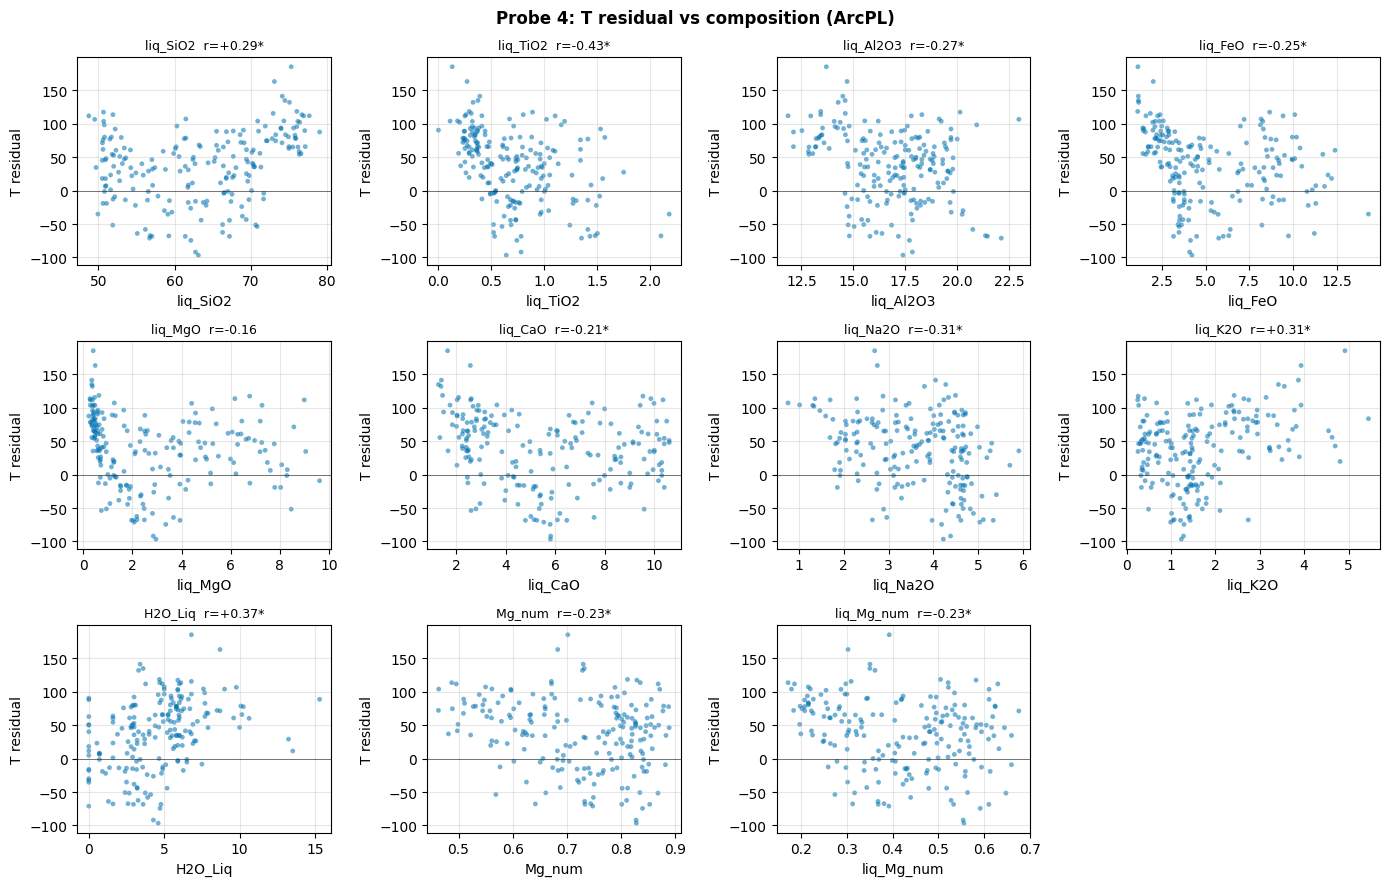

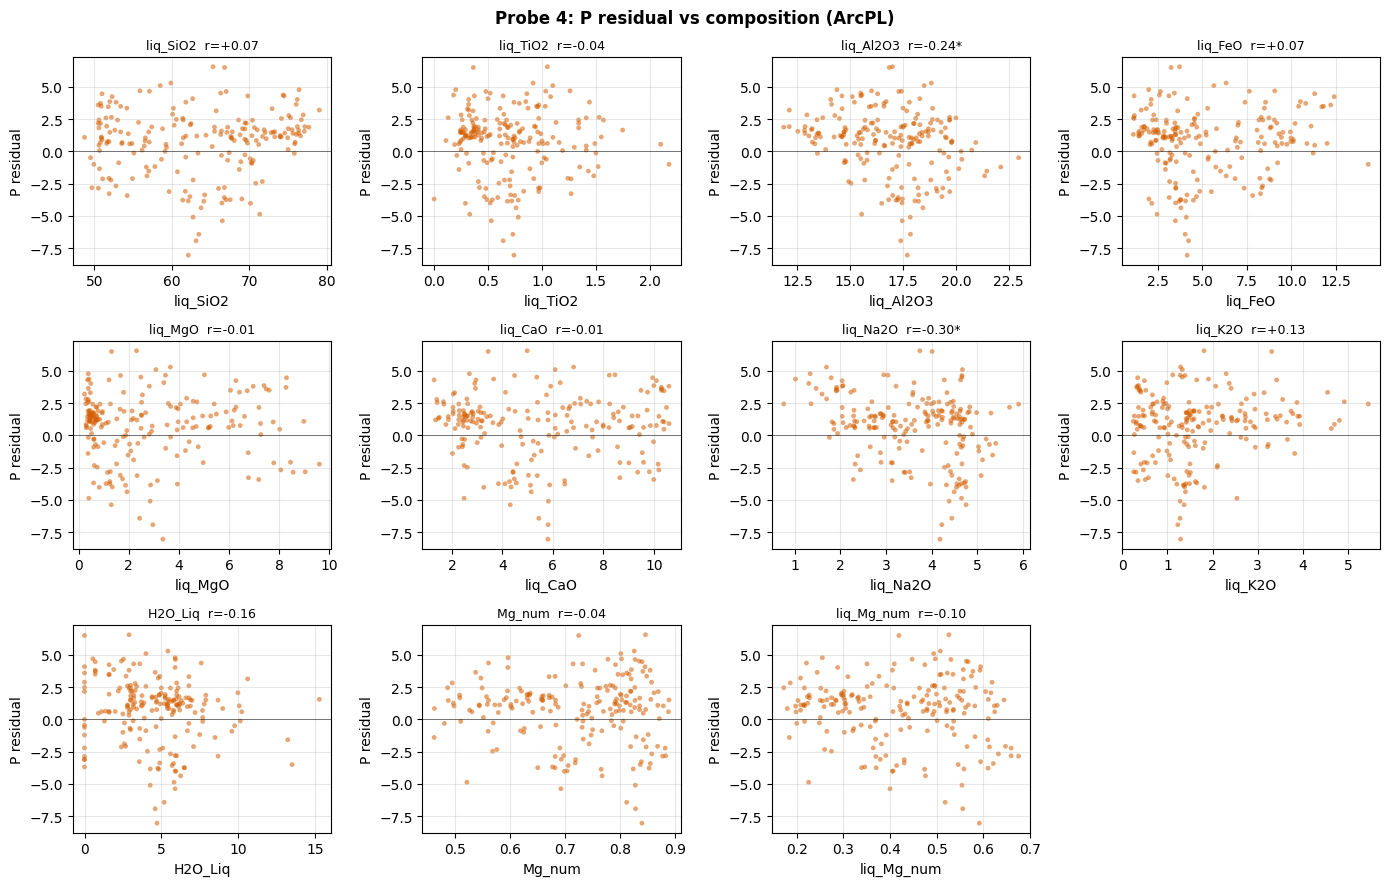

In [5]:
feature_cols = [c for c in ['liq_SiO2', 'liq_TiO2', 'liq_Al2O3', 'liq_FeO',
                             'liq_MgO', 'liq_CaO', 'liq_Na2O', 'liq_K2O',
                             'H2O_Liq', 'Mg_num', 'liq_Mg_num']
                if c in arcpl.columns]
print(f'feature_cols available: {feature_cols}')

probe4_rows = []
for f in feature_cols:
    fx = arcpl[f].astype(float)
    fx = fx.fillna(fx.median())
    for tgt, resid_col in [('T', 'T_resid'), ('P', 'P_resid')]:
        y = arcpl[resid_col].values.astype(float)
        m = np.isfinite(fx.values) & np.isfinite(y)
        r, p = stats.pearsonr(fx.values[m], y[m])
        probe4_rows.append({'target': tgt, 'feature': f, 'pearson_r': float(r),
                            'p_value': float(p),
                            'significant': bool(abs(r) > 0.2 and p < 0.05)})
probe4 = pd.DataFrame(probe4_rows)
probe4.to_csv(RESULTS / 'nb07b_probe4_composition_corr.csv', index=False)

for tgt in ['T', 'P']:
    print(f'\n{tgt} residual vs composition features (|r|>0.2 & p<0.05 marked *):')
    sub = probe4[probe4.target == tgt].sort_values('pearson_r', key=lambda s: s.abs(), ascending=False)
    for _, row in sub.iterrows():
        star = ' *' if row.significant else ''
        print(f'  {row.feature:<14} r = {row.pearson_r:+.3f}  p = {row.p_value:.3g}{star}')

# Small-multiples plot: residual vs each feature, colored by target
n_feat = len(feature_cols)
cols = min(4, n_feat)
rows = (n_feat + cols - 1) // cols
for tgt, resid_col, color in [('T', 'T_resid', '#0072B2'), ('P', 'P_resid', '#D55E00')]:
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.0))
    axes = np.atleast_1d(axes).flatten()
    for i, f in enumerate(feature_cols):
        ax = axes[i]
        x = arcpl[f].astype(float).fillna(arcpl[f].astype(float).median()).values
        y = arcpl[resid_col].values
        r, p = stats.pearsonr(x[np.isfinite(y)], y[np.isfinite(y)])
        ax.scatter(x, y, s=12, alpha=0.55, color=color, edgecolor='none')
        ax.axhline(0, color='k', lw=0.7, alpha=0.5)
        ax.set_xlabel(f)
        ax.set_ylabel(f'{tgt} residual')
        sig = '*' if (abs(r) > 0.2 and p < 0.05) else ''
        ax.set_title(f'{f}  r={r:+.2f}{sig}', fontsize=9)
        ax.grid(True, alpha=0.3)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(f'Probe 4: {tgt} residual vs composition (ArcPL)', fontweight='bold')
    fig.tight_layout()
    for ext in ('png', 'pdf'):
        fig.savefig(FIGURES / f'fig_nb07b_bias_vs_composition_{tgt}.{ext}',
                    dpi=300 if ext == 'png' else None, bbox_inches='tight')
    plt.show(); plt.close(fig)

## Probe 5 -- Compare ArcPL residual pattern to in-distribution test residuals

We use NB07's held-out test predictions as the in-distribution reference
since `nb07_oof_predictions_train.csv` is not materialized in this repo.

Statistic              ArcPL        Test set      Arc - Test
--- T (C) ---
  Mean residual:           +37.32       -5.53      +42.86
  Median residual:         +43.47      -14.97      +58.43
  Slope resid vs pred:    -0.0503     +0.0884     -0.1388
  25/75 percentile:     [-1.3, +75.8]   [-48.6, +29.1]
--- P (kbar) ---
  Mean residual:            +0.69       -0.51       +1.20
  Median residual:          +1.13       +0.00       +1.13
  Slope resid vs pred:    -0.2145     -0.0960     -0.1184
  25/75 percentile:     [-0.6, +2.2]   [-3.3, +1.3]


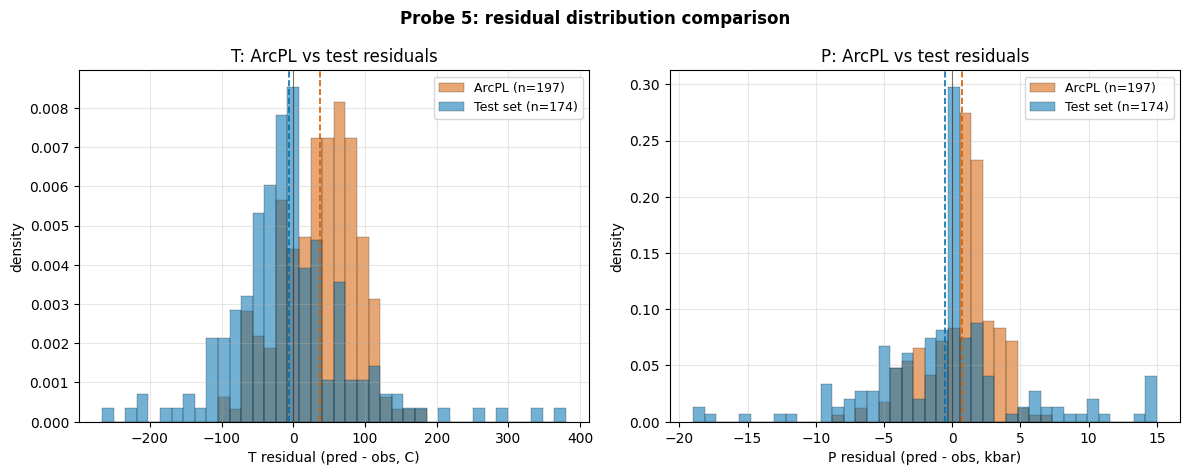

In [6]:
probe5_rows = []
for tgt, a_pred, a_resid, t_pred, t_resid, unit in [
        ('T', 'T_pred', 'T_resid', 'T_rf_raw', 'T_resid', 'C'),
        ('P', 'P_pred', 'P_resid', 'P_rf_raw', 'P_resid', 'kbar')]:
    a_slope, a_icpt, a_r, a_p, _ = stats.linregress(arcpl[a_pred], arcpl[a_resid])
    t_slope, t_icpt, t_r, t_p, _ = stats.linregress(test[t_pred], test[t_resid])
    row = {
        'target':        tgt, 'unit': unit,
        'arc_mean':      float(arcpl[a_resid].mean()),
        'arc_median':    float(arcpl[a_resid].median()),
        'arc_q25':       float(arcpl[a_resid].quantile(0.25)),
        'arc_q75':       float(arcpl[a_resid].quantile(0.75)),
        'arc_slope':     float(a_slope),
        'arc_r':         float(a_r),
        'test_mean':     float(test[t_resid].mean()),
        'test_median':   float(test[t_resid].median()),
        'test_q25':      float(test[t_resid].quantile(0.25)),
        'test_q75':      float(test[t_resid].quantile(0.75)),
        'test_slope':    float(t_slope),
        'test_r':        float(t_r),
    }
    row['mean_diff']   = row['arc_mean']  - row['test_mean']
    row['slope_diff']  = row['arc_slope'] - row['test_slope']
    probe5_rows.append(row)
probe5 = pd.DataFrame(probe5_rows)
probe5.to_csv(RESULTS / 'nb07b_probe5_arcpl_vs_test.csv', index=False)

print('Statistic              ArcPL        Test set      Arc - Test')
for _, r in probe5.iterrows():
    print(f'--- {r.target} ({r.unit}) ---')
    print(f'  Mean residual:        {r.arc_mean:+9.2f}   {r.test_mean:+9.2f}   {r.mean_diff:+9.2f}')
    print(f'  Median residual:      {r.arc_median:+9.2f}   {r.test_median:+9.2f}   '
          f'{r.arc_median - r.test_median:+9.2f}')
    print(f'  Slope resid vs pred:  {r.arc_slope:+9.4f}   {r.test_slope:+9.4f}   {r.slope_diff:+9.4f}')
    print(f'  25/75 percentile:     [{r.arc_q25:+.1f}, {r.arc_q75:+.1f}]   '
          f'[{r.test_q25:+.1f}, {r.test_q75:+.1f}]')

# Overlaid histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, tgt, a_col, t_col, unit in [(axes[0], 'T', 'T_resid', 'T_resid', 'C'),
                                     (axes[1], 'P', 'P_resid', 'P_resid', 'kbar')]:
    a = arcpl[a_col].dropna().values
    t = test[t_col].dropna().values
    bins = np.histogram_bin_edges(np.concatenate([a, t]), bins=40)
    ax.hist(a, bins=bins, density=True, color='#D55E00', alpha=0.55,
            edgecolor='black', linewidth=0.3, label=f'ArcPL (n={len(a)})')
    ax.hist(t, bins=bins, density=True, color='#0072B2', alpha=0.55,
            edgecolor='black', linewidth=0.3, label=f'Test set (n={len(t)})')
    ax.axvline(np.mean(a), color='#D55E00', lw=1.2, ls='--')
    ax.axvline(np.mean(t), color='#0072B2', lw=1.2, ls='--')
    ax.axvline(0, color='k', lw=0.8, alpha=0.5)
    ax.set_xlabel(f'{tgt} residual (pred - obs, {unit})')
    ax.set_ylabel('density')
    ax.set_title(f'{tgt}: ArcPL vs test residuals')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle('Probe 5: residual distribution comparison', fontweight='bold')
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(FIGURES / f'fig_nb07b_residual_distribution_comparison.{ext}',
                dpi=300 if ext == 'png' else None, bbox_inches='tight')
plt.show(); plt.close(fig)

## Probe 6 -- Test in-domain bias correction on ArcPL (GroupKFold)

In [7]:
arcpl_p6 = arcpl.copy().reset_index(drop=True)
# Group by Citation to prevent within-study leakage
arcpl_p6['_grp'] = arcpl_p6['Citation'].fillna('UNKNOWN').astype(str).values
n_groups = arcpl_p6['_grp'].nunique()
n_splits = min(5, n_groups)
print(f'GroupKFold n_splits={n_splits} (unique citations = {n_groups})')

gkf = GroupKFold(n_splits=n_splits)
arcpl_p6['T_pred_const']  = np.nan
arcpl_p6['T_pred_linear'] = np.nan
arcpl_p6['P_pred_const']  = np.nan
arcpl_p6['P_pred_linear'] = np.nan

for fold, (train_idx, test_idx) in enumerate(gkf.split(arcpl_p6, groups=arcpl_p6['_grp'])):
    for tgt, pred_col, obs_col, out_const, out_lin in [
            ('T', 'T_pred', 'T_C',    'T_pred_const', 'T_pred_linear'),
            ('P', 'P_pred', 'P_kbar', 'P_pred_const', 'P_pred_linear')]:
        tr_pred = arcpl_p6.loc[train_idx, pred_col].values
        tr_obs  = arcpl_p6.loc[train_idx, obs_col].values
        tr_resid = tr_pred - tr_obs
        te_pred = arcpl_p6.loc[test_idx, pred_col].values
        # (a) Constant offset: subtract median train residual
        const_c = float(np.median(tr_resid))
        arcpl_p6.loc[test_idx, out_const]  = te_pred - const_c
        # (b) Linear: fit resid = a*pred + b on train, correct test
        lr = LinearRegression().fit(tr_pred.reshape(-1, 1), tr_resid)
        arcpl_p6.loc[test_idx, out_lin] = te_pred - (lr.coef_[0] * te_pred + lr.intercept_)

def _rmse(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2))) if m.any() else float('nan')

# Bootstrap CI on delta-RMSE
def _boot_delta_rmse(raw_resid, corrected_resid, B=2000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(raw_resid)
    out = np.empty(B)
    for i in range(B):
        idx = rng.integers(0, n, size=n)
        rr = raw_resid[idx]; cr = corrected_resid[idx]
        out[i] = (np.sqrt(np.mean(cr ** 2)) - np.sqrt(np.mean(rr ** 2)))
    return float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))

probe6_rows = []
for tgt, pred_col, obs_col, out_const, out_lin, unit in [
        ('T', 'T_pred', 'T_C',    'T_pred_const', 'T_pred_linear', 'C'),
        ('P', 'P_pred', 'P_kbar', 'P_pred_const', 'P_pred_linear', 'kbar')]:
    obs = arcpl_p6[obs_col].values
    raw_resid    = (arcpl_p6[pred_col].values  - obs)
    const_resid  = (arcpl_p6[out_const].values - obs)
    linear_resid = (arcpl_p6[out_lin].values   - obs)
    rmse_raw    = _rmse(arcpl_p6[pred_col],  obs)
    rmse_const  = _rmse(arcpl_p6[out_const], obs)
    rmse_linear = _rmse(arcpl_p6[out_lin],   obs)
    d_const_lo,  d_const_hi  = _boot_delta_rmse(raw_resid, const_resid)
    d_linear_lo, d_linear_hi = _boot_delta_rmse(raw_resid, linear_resid)
    pct_const  = 100.0 * (rmse_raw - rmse_const)  / rmse_raw
    pct_linear = 100.0 * (rmse_raw - rmse_linear) / rmse_raw
    print(f'\n{tgt} RMSE ({unit}): raw={rmse_raw:.3f}, '
          f'const={rmse_const:.3f} ({pct_const:+.1f}% vs raw), '
          f'linear={rmse_linear:.3f} ({pct_linear:+.1f}% vs raw)')
    print(f'  Delta-RMSE 95% CI: const [{d_const_lo:+.3f}, {d_const_hi:+.3f}]  '
          f'linear [{d_linear_lo:+.3f}, {d_linear_hi:+.3f}]')
    probe6_rows.append({
        'target': tgt, 'unit': unit,
        'rmse_raw': rmse_raw, 'rmse_const': rmse_const, 'rmse_linear': rmse_linear,
        'pct_improve_const': pct_const, 'pct_improve_linear': pct_linear,
        'delta_const_lo': d_const_lo,  'delta_const_hi': d_const_hi,
        'delta_linear_lo': d_linear_lo, 'delta_linear_hi': d_linear_hi,
        'const_significant':  bool(d_const_hi  < 0),
        'linear_significant': bool(d_linear_hi < 0),
    })
probe6 = pd.DataFrame(probe6_rows)
probe6.to_csv(RESULTS / 'nb07b_probe6_correction_cv.csv', index=False)

GroupKFold n_splits=5 (unique citations = 19)

T RMSE (C): raw=64.580, const=58.582 (+9.3% vs raw), linear=59.454 (+7.9% vs raw)
  Delta-RMSE 95% CI: const [-11.362, -0.209]  linear [-9.842, -0.160]



P RMSE (kbar): raw=2.628, const=2.687 (-2.2% vs raw), linear=2.910 (-10.7% vs raw)
  Delta-RMSE 95% CI: const [-0.105, +0.235]  linear [+0.136, +0.425]


## Probe 7 -- Decision and recommendation

In [8]:
# Pull evidence from prior probes
probe3 = json.loads((RESULTS / 'nb07b_probe3_linear_fit.json').read_text())
p4 = pd.read_csv(RESULTS / 'nb07b_probe4_composition_corr.csv')
p6 = pd.read_csv(RESULTS / 'nb07b_probe6_correction_cv.csv')
p1 = pd.read_csv(RESULTS / 'nb07b_probe1_bias_stats.csv')

def _arc_mean(t):
    return float(p1[(p1.target == t) & (p1.source == 'ArcPL')].iloc[0]['mean'])
def _test_mean(t):
    return float(p1[(p1.target == t) & (p1.source == 'Test_set')].iloc[0]['mean'])

T_arc, T_test = _arc_mean('T'), _test_mean('T')
P_arc, P_test = _arc_mean('P'), _test_mean('P')
T_r = probe3['T']['r']
P_r = probe3['P']['r']

def _get6(t, key):
    return float(p6[p6.target == t].iloc[0][key])

T_pct_const,  T_pct_linear  = _get6('T', 'pct_improve_const'),  _get6('T', 'pct_improve_linear')
P_pct_const,  P_pct_linear  = _get6('P', 'pct_improve_const'),  _get6('P', 'pct_improve_linear')
T_const_sig,  T_linear_sig  = bool(p6[p6.target == 'T'].iloc[0]['const_significant']),  bool(p6[p6.target == 'T'].iloc[0]['linear_significant'])
P_const_sig,  P_linear_sig  = bool(p6[p6.target == 'P'].iloc[0]['const_significant']),  bool(p6[p6.target == 'P'].iloc[0]['linear_significant'])

sig_comp_T = p4[(p4.target == 'T') & (p4.significant)].sort_values('pearson_r', key=lambda s: s.abs(), ascending=False)
sig_comp_P = p4[(p4.target == 'P') & (p4.significant)].sort_values('pearson_r', key=lambda s: s.abs(), ascending=False)

# Decision logic
def _decide(tgt, arc_mean, test_mean, r, pct_const, pct_linear,
            const_sig, linear_sig, sig_comp_df):
    evidence = []
    evidence.append(f'arc mean residual = {arc_mean:+.2f}, test mean = {test_mean:+.2f} '
                    f'(distribution-shift gap = {arc_mean - test_mean:+.2f})')
    evidence.append(f'pearson(pred, residual) on ArcPL = {r:+.3f}')
    evidence.append(f'in-domain GroupKFold RMSE reduction: const={pct_const:+.1f}% '
                    f'({"sig" if const_sig else "ns"}), '
                    f'linear={pct_linear:+.1f}% ({"sig" if linear_sig else "ns"})')
    n_sig = len(sig_comp_df)
    evidence.append(f'composition features with |r|>0.2 and p<0.05: {n_sig}')
    if n_sig > 0:
        top = ', '.join(f"{row.feature} r={row.pearson_r:+.2f}" for _, row in sig_comp_df.head(3).iterrows())
        evidence.append(f'  top: {top}')

    # Option selection per spec
    if pct_linear >= 20 and linear_sig and abs(r) > 0.1:
        choice = 'C: linear correction'
    elif pct_const >= 20 and const_sig and abs(r) < 0.1:
        choice = 'B: global mean correction'
    elif n_sig >= 3 and pct_linear >= 15:
        choice = 'D: composition-conditional correction'
    else:
        choice = 'A: report uncorrected with caveat'
    return choice, evidence

T_choice, T_evidence = _decide('T', T_arc, T_test, T_r, T_pct_const, T_pct_linear,
                                T_const_sig, T_linear_sig, sig_comp_T)
P_choice, P_evidence = _decide('P', P_arc, P_test, P_r, P_pct_const, P_pct_linear,
                                P_const_sig, P_linear_sig, sig_comp_P)

print('=' * 72)
print('PROBE 7: RECOMMENDATION')
print('=' * 72)
print(f'\nTemperature (T_C) recommendation: Option {T_choice}')
for e in T_evidence:
    print(f'  - {e}')
print(f'\nPressure (P_kbar) recommendation: Option {P_choice}')
for e in P_evidence:
    print(f'  - {e}')

tradeoff = (
    'Tradeoff: any correction trained on ArcPL itself is in-domain for ArcPL '
    'and may not help other arc datasets. Users should be informed whenever '
    'the correction is applied. For manuscript honesty, present both raw and '
    'corrected numbers.'
)
print(f'\n{tradeoff}')

# Persist recommendation
rec = {
    'T': {'choice': T_choice, 'evidence': T_evidence,
          'arc_mean': T_arc, 'test_mean': T_test, 'pearson_r': T_r,
          'pct_improve_const': T_pct_const, 'pct_improve_linear': T_pct_linear},
    'P': {'choice': P_choice, 'evidence': P_evidence,
          'arc_mean': P_arc, 'test_mean': P_test, 'pearson_r': P_r,
          'pct_improve_const': P_pct_const, 'pct_improve_linear': P_pct_linear},
    'tradeoff': tradeoff,
}
(RESULTS / 'nb07b_probe7_recommendation.json').write_text(json.dumps(rec, indent=2))

# Final summary of outputs
print('\n' + '=' * 72)
print('OUTPUTS CREATED BY NB07B')
print('=' * 72)
outs = [
    'results/nb07b_probe1_bias_stats.csv',
    'results/nb07b_probe2_extreme_residuals.csv',
    'results/nb07b_probe3_bias_by_quintile.csv',
    'results/nb07b_probe3_linear_fit.json',
    'results/nb07b_probe4_composition_corr.csv',
    'results/nb07b_probe5_arcpl_vs_test.csv',
    'results/nb07b_probe6_correction_cv.csv',
    'results/nb07b_probe7_recommendation.json',
    'figures/fig_nb07b_arcpl_residual_hist.{png,pdf}',
    'figures/fig_nb07b_bias_vs_prediction.{png,pdf}',
    'figures/fig_nb07b_bias_vs_composition_T.{png,pdf}',
    'figures/fig_nb07b_bias_vs_composition_P.{png,pdf}',
    'figures/fig_nb07b_residual_distribution_comparison.{png,pdf}',
]
for o in outs:
    print(f'  {o}')

PROBE 7: RECOMMENDATION

Temperature (T_C) recommendation: Option A: report uncorrected with caveat
  - arc mean residual = +37.32, test mean = -5.53 (distribution-shift gap = +42.86)
  - pearson(pred, residual) on ArcPL = -0.089
  - in-domain GroupKFold RMSE reduction: const=+9.3% (sig), linear=+7.9% (sig)
  - composition features with |r|>0.2 and p<0.05: 10
  -   top: liq_TiO2 r=-0.43, H2O_Liq r=+0.37, liq_K2O r=+0.31

Pressure (P_kbar) recommendation: Option A: report uncorrected with caveat
  - arc mean residual = +0.69, test mean = -0.51 (distribution-shift gap = +1.20)
  - pearson(pred, residual) on ArcPL = -0.214
  - in-domain GroupKFold RMSE reduction: const=-2.2% (ns), linear=-10.7% (ns)
  - composition features with |r|>0.2 and p<0.05: 2
  -   top: liq_Na2O r=-0.30, liq_Al2O3 r=-0.24

Tradeoff: any correction trained on ArcPL itself is in-domain for ArcPL and may not help other arc datasets. Users should be informed whenever the correction is applied. For manuscript honesty, 